In [59]:
# -*- coding: utf-8 -*-
import os
import sys
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import LineString, Point, box
from shapely.ops import split, unary_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import Wedge, Patch, Circle
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.cm import ScalarMappable
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Circle
from matplotlib.offsetbox import AnchoredOffsetbox, VPacker, HPacker, TextArea, DrawingArea
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib as mpl
import geopandas as gpd
mpl.rcParams['mathtext.default'] = 'regular'
import matplotlib.image as mpimg


In [60]:
# 中文到英文映射
ch_en_map = {
    "北京市": "Beijing", "天津市": "Tianjin", "上海市": "Shanghai", "重庆市": "Chongqing",
    "河北省": "Hebei", "山西省": "Shanxi", "内蒙古自治区": "Inner Mongolia", "辽宁省": "Liaoning",
    "吉林省": "Jilin", "黑龙江省": "Heilongjiang", "江苏省": "Jiangsu", "浙江省": "Zhejiang",
    "安徽省": "Anhui", "福建省": "Fujian", "江西省": "Jiangxi", "山东省": "Shandong",
    "河南省": "Henan", "湖北省": "Hubei", "湖南省": "Hunan", "广东省": "Guangdong",
    "广西壮族自治区": "Guangxi", "海南省": "Hainan", "四川省": "Sichuan", "贵州省": "Guizhou",
    "云南省": "Yunnan", "西藏自治区": "Tibet", "陕西省": "Shaanxi", "甘肃省": "Gansu",
    "青海省": "Qinghai", "宁夏回族自治区": "Ningxia", "新疆维吾尔自治区": "Sinkiang",
    "台湾省": "Taiwan", "香港特别行政区": "Hong Kong", "澳门特别行政区": "Macau"
}

In [61]:
# ======================================== 0. 控制台 UTF-8 & 中文字体 =====================================
if os.name == 'nt':
    os.system('chcp 65001 >nul')
    if hasattr(sys.stdout, "reconfigure"):
        sys.stdout.reconfigure(encoding='utf-8')

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False

# —— 1. 路径设定 ——  
prov_shp = r"D:\Research\China_E_C\Map\CN_Map\CN_Province.shp"
city_shp = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\CN_Prefecture.shp"
nine_shp = r"D:\Research\China_E_C\Map\CN_Map\Jiu_Duan_Xian.shp"

out_dir = r"D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50"
os.makedirs(out_dir, exist_ok=True)

In [62]:
#============================== 2. 读取 & 投影 ===============================  
provinces = gpd.read_file(city_shp)

prov = gpd.read_file(prov_shp, encoding='utf-8')
nine = gpd.read_file(nine_shp, encoding='utf-8')

# 2.1 用于切分的地理 CRS
prov_geo = prov.to_crs(epsg=4326)

# 2.2 投影到 EPSG:2343，用于最终绘图
prov_2343 = prov.to_crs(epsg=2343)
nine_2343 = nine.to_crs(epsg=2343)

# 2.3 剔除小岛
def remove_small_islands(geom, min_area=5e9):
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    return geom if geom.area > min_area else geom

prov_2343["geometry"] = prov_2343["geometry"].apply(lambda g: remove_small_islands(g, min_area=5e9))


[-2244505.40452648  2012980.3232581   2720859.35887738  6098749.96582366]


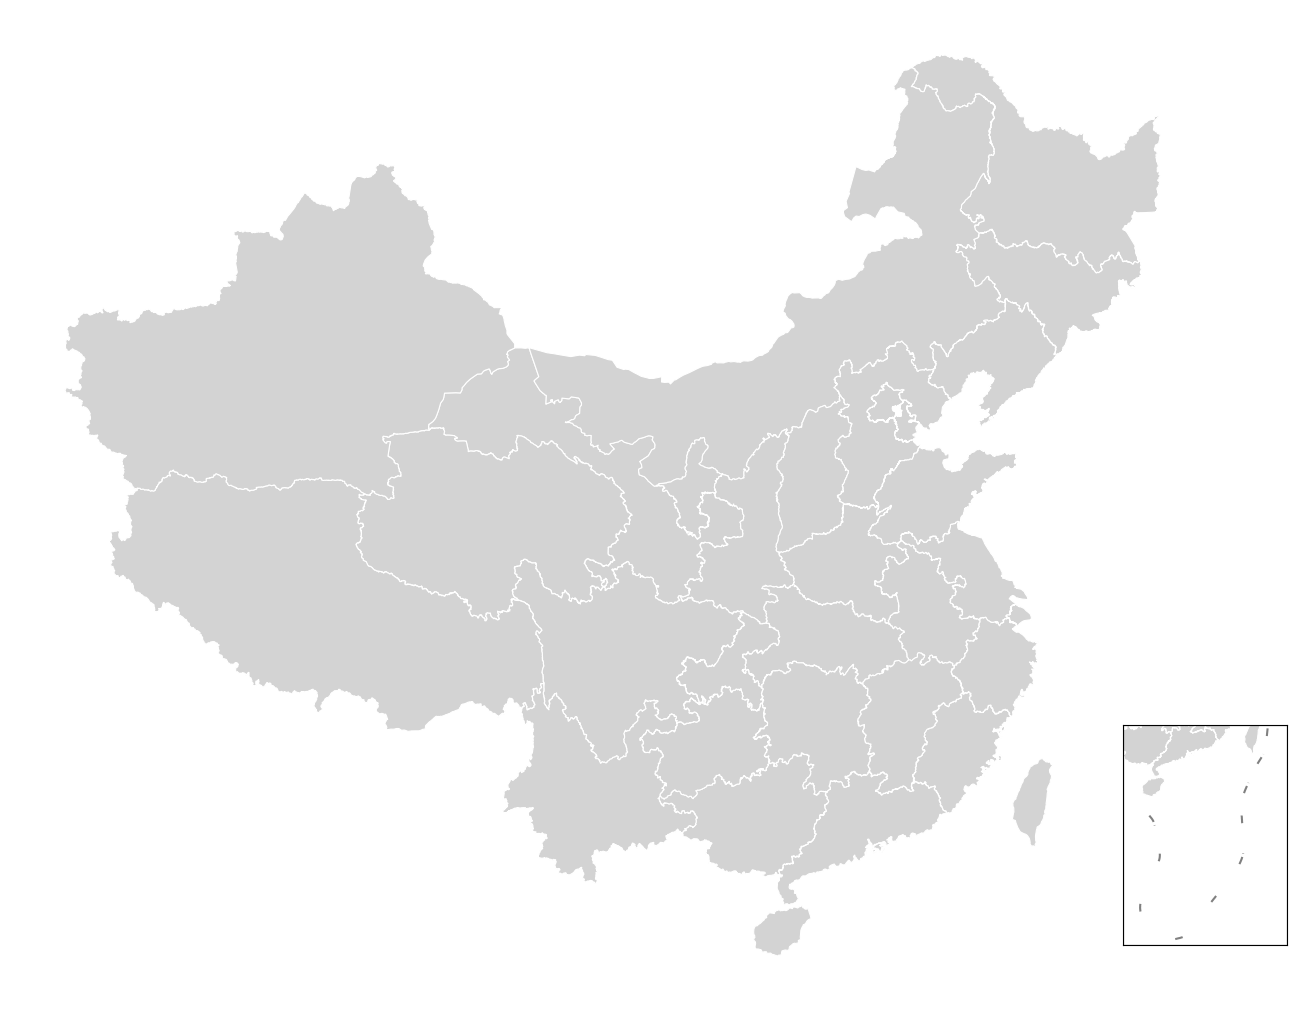

In [63]:
# ============================ 3. 绘制主图 + 九段线 inset ==============================  
fig, ax = plt.subplots(figsize=(16,10),constrained_layout=True)
print(prov_2343.total_bounds)
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
FigureCanvas(fig)
fig.canvas.draw()
albers_proj = 'EPSG:2343'
# 3.1 主图：省界背景
prov_2343.plot(ax=ax, facecolor="lightgrey", edgecolor='white', linewidth=0.8, zorder=1)

#nine_2343.plot(ax=ax, color='gray',  linewidth=1.5,  zorder=2)
ax.set_axis_off()
# 3.2 九段线 inset（保持和之前一致）
# 地理 CRS 下裁剪框
bbox_geo = box(106.5, 2.8, 123.0, 24.5)
# 投影裁剪框
bbox_2343 = gpd.GeoSeries([bbox_geo], crs=4326).to_crs(epsg=2343).iloc[0]
# 裁剪图层
prov_crop = prov_2343[prov_2343.intersects(bbox_2343)]
nine_crop = nine_2343[nine_2343.intersects(bbox_2343)]
axins = fig.add_axes([0.78, 0.06, 0.18, 0.22])

#axins = inset_axes(ax, width='20%', height='20%', loc='lower right', bbox_to_anchor=(0.11, 0.27, 1.0, 1.0), bbox_transform=ax.transAxes, borderpad=0)
prov_crop.plot(ax=axins, facecolor="lightgrey", edgecolor='white', linewidth=0.8, zorder=1)
nine_crop.plot(ax=axins, color='gray', linewidth=1.5, linestyle='--', zorder=2)

# 固定 inset 范围
minx, miny, maxx, maxy = bbox_2343.bounds
axins.set_xlim(minx, maxx)
axins.set_ylim(miny, maxy)
axins.set_xticks([])
axins.set_yticks([])

rect = Rectangle((0, 0), 1, 1, transform=axins.transAxes, fill=False, edgecolor='black', linewidth=0.8)

axins.add_patch(rect)
ax.axis('off')


def remove_small_islands(geom, min_area=5e9):
    """
    过滤掉面积小于 min_area 的小岛。
    geom: Polygon 或 MultiPolygon
    """
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    # 单面片
    return geom if geom.area > min_area else geom



        

In [64]:
# ============================== 4. 基于地级市将内蒙古分为蒙西／蒙东两块 =================================

# 4.1 读取并投影地级市 shp（CN_Prefecture.shp）
city = gpd.read_file(city_shp, encoding='utf-8').to_crs(epsg=2343)

# 4.2 筛选“内蒙古自治区”下属所有地级市
im_city = city[city['省']=="内蒙古自治区"].copy()

# 4.3 定义蒙西／蒙东的地市名单
east_list = ["赤峰市","通辽市","兴安盟","呼伦贝尔市"]

west_list = [c for c in im_city['市'].unique() if c not in east_list]

# 4.4 新增 region 列，然后 dissolve 合并
im_city['region'] = im_city['市'].apply(
    lambda s: 'W_InnerMongo' if s in west_list
              else ('E_InnerMongo' if s in east_list else None)
)

im_west = (
    im_city[im_city['region']=="W_InnerMongo"]
    .dissolve(by='region')
    .reset_index()   # 把 region 提升为一列
)

im_east = (
    im_city[im_city['region']=="E_InnerMongo"]
    .dissolve(by='region')
    .reset_index()
)

In [65]:
# ============================== 5. 绘制电网区域边框 ==============================
prov_2343['province_cn'] = prov_2343['省']
def remove_small_islands(geom, min_area=5e9):
    """
    过滤掉面积小于 min_area 的小岛。
    geom: Polygon 或 MultiPolygon
    """
    if isinstance(geom, MultiPolygon):
        parts = [p for p in geom.geoms if p.area > min_area]
        if not parts:
            return geom
        return parts[0] if len(parts)==1 else MultiPolygon(parts)
    # 单面片
    return geom if geom.area > min_area else geom

# —— 4.5 定义电网区域及样式 ——  
grid_regions = {
    'NE': { 'province_cn': ["辽宁省","吉林省","黑龙江省"],
            'use_im_east': True,
            'style': dict(edgecolor="#4e79a7", linewidth=2.3, linestyle='--') },

    'NC': { 'province_cn': ["山东省","山西省","河北省","天津市","北京市"],
            'use_im_west': True,
            'style': dict(edgecolor="#2a4651", linewidth=2.3, linestyle='--') },

    'EC': { 'province_cn': ["上海市","江苏省","浙江省","安徽省","福建省"],
            'style': dict(edgecolor="#5e8440", linewidth=2.3, linestyle='--') },

    'HC': { 'province_cn': ["湖南省","湖北省","江西省","河南省"],
            'style': dict(edgecolor="#c7a76c", linewidth=2.3, linestyle='--') },

    'SW': { 'province_cn': ["四川省","重庆市","西藏自治区"],
            'style': dict(edgecolor="#841e2a", linewidth=2.3, linestyle='--') },

    'NW': { 'province_cn': ["陕西省","甘肃省","宁夏回族自治区","青海省","新疆维吾尔自治区"],
            'style': dict(edgecolor="#c55274", linewidth=2.3, linestyle='--') },

    'SC': { 'province_cn': ["广东省","广西壮族自治区","海南省","云南省","贵州省"],
            'style': dict(edgecolor="#347219", linewidth=2.3, linestyle='--') }
}

# 构造每个区域的合并几何并带上样式
grid_borders = []
for code, info in grid_regions.items():
    # 取普通省份的 geometry
    geoms = prov_2343[prov_2343['province_cn'].isin(info['province_cn'])].geometry.tolist()
    # 加蒙东/蒙西
    if info.get('use_im_east'):
        geoms.append(im_east.geometry.iloc[0])
    if info.get('use_im_west'):
        geoms.append(im_west.geometry.iloc[0])
    # 合并并过滤小岛
    merged = unary_union(geoms)
    merged = remove_small_islands(merged, min_area=5e9)
    # 一次性 append region, geometry, style
    grid_borders.append({
        'region': code,
        'geometry': merged,
        'style': info['style']
    })

grid_gdf = gpd.GeoDataFrame(grid_borders, crs=prov_2343.crs)

# 按区域分别绘制
for _, row in grid_gdf.iterrows():
    gpd.GeoSeries(row.geometry).boundary.plot(
        ax=ax, zorder=3, **row['style']
    )

legend_handles = []
for code, info in grid_regions.items():
    style = info['style']
    # 用 Line2D 构造一个仅用于图例的线条示例
    line = Line2D(
        [0], [0],
        color=style['edgecolor'],
        linewidth=style['linewidth'],
        linestyle=style['linestyle']
    )
    legend_handles.append((line, code))

# 拆解 handles, labels
handles, labels = zip(*legend_handles)

# ============================== 固定地图位置和大小 ==============================

# 先完成当前 constrained_layout 的计算
fig.canvas.draw()

# 保存主地图和南海插图的位置
main_ax_position = ax.get_position().frozen()
inset_ax_position = axins.get_position().frozen()

# 保存主地图显示范围
main_xlim = ax.get_xlim()
main_ylim = ax.get_ylim()

# 关闭自动布局，避免后续图例影响地图位置和尺寸
try:
    fig.set_layout_engine(None)
except (AttributeError, TypeError):
    fig.set_constrained_layout(False)

# 恢复并固定主地图和南海插图的位置
ax.set_position(main_ax_position)
axins.set_position(inset_ax_position)

# 恢复地图显示范围
ax.set_xlim(main_xlim)
ax.set_ylim(main_ylim)

# 后续绘制网络连线时，禁止 Matplotlib 自动改变地图范围
ax.set_autoscale_on(False)
axins.set_autoscale_on(False)

# 在图上添加图例
leg_region = ax.legend(
    handles,
    labels,
    title="Province Region",
    loc="lower left",
    bbox_to_anchor=(0.18, 0.005),

    # 明确使用主地图 axes 坐标
    bbox_transform=ax.transAxes,

    frameon=False,
    edgecolor="gray",
    ncol=2,
    fontsize=15.8,
    columnspacing=1.5,
    labelspacing=1.19,
    title_fontsize=18.2
)

leg_region.get_title().set_fontweight("bold")

# 图例不参与布局计算，避免改变地图位置和大小
leg_region.set_in_layout(False)

# 必须保留第一个图例，否则创建第二个图例后它会被替换
ax.add_artist(leg_region)


<Figure size 640x480 with 0 Axes>

In [66]:
# ============================== 7. 读取省际容量并绘制连线（分段线宽 + 数学符号图例） ==============================

# 7.1 数据路径
# 如果 Excel 文件和 notebook 在同一目录，直接这样写即可；
# 如果不在同一目录，请改成你的绝对路径。
net_xlsx_path = r"E_Net_CN50.xlsx"
contrast_xlsx_path = r"D:\Research\China_E_C\Map\CN_Map_WGS1984\Prov_contrast.xlsx"

net_sheet_name = "U_Eli_acm50"
contrast_sheet_name = "Sheet1"

# 7.2 读取省际电力网络传输线容量
# E_Net_CN50.xlsx 当前结构：
# 第1列：AC/DC 类型
# 第2列：送端省份简称
# 第3列：受端省份简称
# 第4列：容量，单位 GW
df_line = pd.read_excel(
    net_xlsx_path,
    sheet_name=net_sheet_name,
    header=None,
    usecols=[0, 1, 2, 3]
)

df_line.columns = ["ACDC", "Origin_short", "Destination_short", "Cap"]

df_line["ACDC"] = df_line["ACDC"].astype(str).str.strip().str.upper()
df_line["Origin_short"] = df_line["Origin_short"].astype(str).str.strip()
df_line["Destination_short"] = df_line["Destination_short"].astype(str).str.strip()
df_line["Cap"] = pd.to_numeric(df_line["Cap"], errors="coerce")

# 删除空行、容量异常行
df_line = df_line[
    df_line["ACDC"].isin(["AC", "DC"]) &
    df_line["Origin_short"].notna() &
    df_line["Destination_short"].notna() &
    df_line["Cap"].notna() &
    (df_line["Cap"] > 0)
].copy()

# 7.3 读取省份简称对照表
# Prov_contrast.xlsx 当前结构：
# Prov_name  : 英文省名
# Prov_short : 省份简称
prov_contrast = pd.read_excel(
    contrast_xlsx_path,
    sheet_name=contrast_sheet_name
)

prov_contrast["Prov_name"] = prov_contrast["Prov_name"].astype(str).str.strip()
prov_contrast["Prov_short"] = prov_contrast["Prov_short"].astype(str).str.strip()

prov_contrast = prov_contrast[
    prov_contrast["Prov_name"].notna() &
    prov_contrast["Prov_short"].notna() &
    (prov_contrast["Prov_name"] != "nan") &
    (prov_contrast["Prov_short"] != "nan")
].copy()

short_to_name = dict(zip(
    prov_contrast["Prov_short"],
    prov_contrast["Prov_name"]
))

# 将简称转换为英文省名
df_line["Origin"] = df_line["Origin_short"].map(short_to_name)
df_line["Destination"] = df_line["Destination_short"].map(short_to_name)

# 检查简称是否全部匹配成功
missing_origin = sorted(df_line.loc[df_line["Origin"].isna(), "Origin_short"].unique())
missing_dest = sorted(df_line.loc[df_line["Destination"].isna(), "Destination_short"].unique())
missing_short = sorted(set(missing_origin + missing_dest))

if len(missing_short) > 0:
    print("[Warning] 以下省份简称未能在 Prov_contrast.xlsx 中匹配：")
    print(missing_short)

# 删除未匹配成功的线路
df_line = df_line[
    df_line["Origin"].notna() &
    df_line["Destination"].notna()
].copy()

print("有效省际线路数量：", len(df_line))
print("容量范围 GW：", df_line["Cap"].min(), "-", df_line["Cap"].max())

# 7.4 中英映射与质心缓存，EPSG:2343
# ch_en_map 已在前文定义：
# 中文省名 -> 英文省名
en2cn = {en: cn for cn, en in ch_en_map.items()}

centroid_cache = {}

# 注意：Prov_contrast.xlsx 中使用的是 W_InnerMongolia / E_InnerMongolia
# 这里同时兼容你前面代码里使用过的 W_InnerMongo / E_InnerMongo
centroid_cache["W_InnerMongolia"] = im_west.geometry.iloc[0].representative_point()
centroid_cache["E_InnerMongolia"] = im_east.geometry.iloc[0].representative_point()
centroid_cache["W_InnerMongo"] = im_west.geometry.iloc[0].representative_point()
centroid_cache["E_InnerMongo"] = im_east.geometry.iloc[0].representative_point()

def get_centroid_region(region_name: str):
    """
    根据英文省名或蒙西/蒙东名称返回绘图用点位。
    普通省份：通过 ch_en_map 转换为中文省名后，在 prov_2343 中定位。
    蒙西/蒙东：直接使用前文 im_west / im_east 的 representative_point。
    """
    region_name = str(region_name).strip()

    if region_name in centroid_cache:
        return centroid_cache[region_name]

    if region_name not in en2cn:
        raise KeyError(f"[NameMap] 英文省名未能映射到中文省名: {region_name}")

    cn_name = en2cn[region_name]

    sub = prov_2343[prov_2343["province_cn"] == cn_name]

    if sub.empty:
        raise KeyError(f"[Province] 省份未在 shapefile 中找到: {cn_name}，英文名为 {region_name}")

    geom_union = unary_union(sub.geometry)

    # representative_point 比 centroid 更稳，避免质心落到多面省份外部或边界外
    pt = geom_union.representative_point()

    centroid_cache[region_name] = pt
    return pt

# 7.5 线宽分段映射
# 当前 E_Net_CN50.xlsx 的容量大致分布在 0.6–40 GW。
# 原来的 10–30 GW 区间过宽，因此改为 10–20 和 20–40。
GW_bins_prov = [0, 5, 10, 20, 50]
bin_labels = ["0 - 5", "5 - 10", "10 - 20", "20 - 50"]

# 保持原有线宽层级风格
line_widths = [1.8, 2.9, 4.3, 5.5]

def capacity_to_width(cap):
    """
    将容量映射为分段线宽。
    规则：
    0 <= Cap < 5     -> 1.5
    5 <= Cap < 10    -> 2.5
    10 <= Cap < 20   -> 3.5
    20 <= Cap <= 40  -> 4.5
    """
    cap = float(cap)

    idx = np.searchsorted(GW_bins_prov, cap, side="right") - 1
    idx = max(0, min(idx, len(line_widths) - 1))

    return line_widths[idx]

# 7.6 样式：保持原代码颜色和线型
style_by_type = {
    "AC": dict(color="#1f77b4", linestyle="-", marker="o"),
    "DC": dict(color="#ff0000", linestyle="--", marker="o")
}

first_plot = {"prov_ac": True, "prov_dc": True}

# 7.7 绘制省-省连线 + 端点
for prov_type, key in [("AC", "prov_ac"), ("DC", "prov_dc")]:

    sub = df_line[df_line["ACDC"] == prov_type].copy()

    if sub.empty:
        continue

    for _, row in sub.iterrows():

        o_name = row["Origin"]
        d_name = row["Destination"]
        cap = row["Cap"]
        lw = capacity_to_width(cap)

        try:
            p_o = get_centroid_region(o_name)
            p_d = get_centroid_region(d_name)

        except KeyError as e:
            print("[Skip]", e)
            continue

        sty = style_by_type[prov_type]

        # 绘制连线
        ax.plot(
            [p_o.x, p_d.x],
            [p_o.y, p_d.y],
            color=sty["color"],
            linestyle=sty["linestyle"],
            linewidth=lw,
            alpha=0.8,
            label=prov_type if first_plot[key] else "_nolegend_",
            zorder=4
        )

        # 绘制送端点
        ax.scatter(
            [p_o.x],
            [p_o.y],
            color=sty["color"],
            s=30,
            zorder=5,
            edgecolor="black",
            linewidth=0.3,
            marker=sty["marker"]
        )

        # 绘制受端点
        ax.scatter(
            [p_d.x],
            [p_d.y],
            color=sty["color"],
            s=30,
            zorder=5,
            edgecolor="black",
            linewidth=0.3,
            marker=sty["marker"]
        )

    first_plot[key] = False

# 7.8 AC / DC 类型图例 + 容量分段图例
legend_handles = []
legend_labels = []

# AC 图例
ac_style = style_by_type["AC"]

legend_handles.append(Line2D(
    [0, 1],
    [0, 0],
    color=ac_style["color"],
    linestyle=ac_style["linestyle"],
    linewidth=2,
    marker=ac_style["marker"],
    markersize=6,
    markerfacecolor=ac_style["color"],
    markeredgecolor="black",
    markeredgewidth=0.3
))
legend_labels.append("AC")

for lbl, lw in zip(bin_labels, line_widths):
    legend_handles.append(Line2D(
        [0, 1],
        [0, 0],
        color=ac_style["color"],
        linestyle=ac_style["linestyle"],
        linewidth=lw
    ))
    legend_labels.append(lbl)

# DC 图例
dc_style = style_by_type["DC"]

legend_handles.append(Line2D(
    [0, 1],
    [0, 0],
    color=dc_style["color"],
    linestyle=dc_style["linestyle"],
    linewidth=2,
    marker=dc_style["marker"],
    markersize=6,
    markerfacecolor=dc_style["color"],
    markeredgecolor="black",
    markeredgewidth=0.3
))
legend_labels.append("DC")

for lbl, lw in zip(bin_labels, line_widths):
    legend_handles.append(Line2D(
        [0, 1],
        [0, 0],
        color=dc_style["color"],
        linestyle=dc_style["linestyle"],
        linewidth=lw
    ))
    legend_labels.append(lbl)

# 图例位置保持原代码设置
# ============================== Transmission Capacity 图例 ==============================

# 只调整这两个参数即可移动图例
CAPACITY_LEGEND_X = -0.2
CAPACITY_LEGEND_Y = 0.005

leg_capacity = ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    title="Power Transmission Capacity (GW)",
    loc="lower left",

    bbox_to_anchor=(
        CAPACITY_LEGEND_X,
        CAPACITY_LEGEND_Y
    ),

    # 明确相对于主地图 axes 定位
    bbox_transform=ax.transAxes,

    frameon=False,
    ncol=2,
    columnspacing=1.5,
    labelspacing=0.76,
    fontsize=15.8,
    title_fontsize=18
)

leg_capacity.get_title().set_fontweight("bold")

# 该图例不参与布局计算，不会挤压或移动地图
leg_capacity.set_in_layout(False)

有效省际线路数量： 76
容量范围 GW： 0.6 - 52.5


In [67]:
# === 保存图片 ===
out_file = os.path.join(out_dir, "ENet_CN50"".png")

# ============================== 保存前再次锁定地图 ==============================

ax.set_position(main_ax_position)
axins.set_position(inset_ax_position)

ax.set_xlim(main_xlim)
ax.set_ylim(main_ylim)

fig.canvas.draw()

fig.savefig(
    out_file,
    dpi=600,

    # 根据地图和图例的真实边界扩展最终输出画布
    bbox_inches="tight",

    # 两个图例被 set_in_layout(False) 排除后，
    # 保存时需要显式要求 Matplotlib 把它们计入边界
    bbox_extra_artists=(
        leg_region,
        leg_capacity
    ),

    # 图片最外围留白
    pad_inches=0.1
)
print(f"图片已保存到: {out_file}")

from IPython.display import Image, display
display(Image(filename=out_file))

图片已保存到: D:\Research\China_E_C\Paper_Fig\Fig_4cases\EC_Network\CN50\ENet_CN50.png
